# Nobel Prize Laureates: Data Analysis and Visualization

## Project Overview

The Nobel Prize has been one of the world's most prestigious international awards since 1901. Nobel Prizes are awarded annually for achievements in **Chemistry, Literature, Physics, Physiology or Medicine, Economics, and Peace**. In addition to the recognition and prize money, Nobel laureates receive a gold medal featuring Alfred Nobel, who established the prizes.

In this project, I analyze Nobel Prize laureate data covering the period from **1901 to 2023**. The dataset was obtained from the **Nobel Prize API** and is provided in the `nobel.csv` file.

The purpose of the analysis is to explore patterns in Nobel Prize awards by **sex, birth country, decade, category, and individual laureate**. In addition to answering the required questions, I create visualizations to make several of the patterns easier to interpret.

## Data and Variables

The analysis is based primarily on the following columns from the `nobel` dataset:

* **`sex`** — the recorded sex of the laureate.
* **`birth_country`** — the country in which the laureate was born.
* **`year`** — the year the Nobel Prize was awarded.
* **`category`** — the Nobel Prize category.
* **`full_name`** — the full name of the individual or organization receiving the prize.

A new **`decade`** variable is also created from `year`. For example, a year such as 1964 is converted to the decade 1960.

## Methodology

The analysis uses the **tidyverse**, including `dplyr` and `ggplot2`, to clean, summarize, analyze, and visualize the data.

The main steps are:

1. **Inspect the dataset** using `glimpse()` and `head()` to understand its structure and review the first observations.
2. **Group and count laureates** by variables such as `sex` and `birth_country` to identify the most common groups.
3. **Create derived variables**, including the `decade` variable and logical indicators such as whether a laureate was born in the United States or was female.
4. **Calculate proportions** by grouping the data by decade or by decade and Nobel category and calculating the mean of logical indicators or the ratio of female laureates to total laureates.
5. **Sort and select results** using functions such as `arrange()` and `slice()` to identify the highest or earliest values.
6. **Create lists and character results** in the format required for the project questions.
7. **Visualize selected results** using column charts, faceted column charts, and a line chart.

## Questions Analyzed

The project answers six main questions:

### 1. Most commonly awarded sex

I count the number of laureates recorded under each value of `sex` and identify the group with the highest count.

### 2. Most common birth country

I count laureates by `birth_country` and identify the country associated with the largest number of laureates.

### 3. Decade with the highest proportion of US-born laureates

I create a `decade` variable and determine the proportion of laureates born in the United States for each decade. Missing birth-country values are excluded from the proportion calculation.

### 4. Decade-category pair with the highest proportion of female laureates

I calculate the proportion of female laureates within each **decade and Nobel Prize category**. Missing sex values are excluded from the calculation so that the denominator represents laureates with known sex.

### 5. First woman to receive a Nobel Prize

I filter the dataset to female laureates, order the observations chronologically, and identify the earliest Nobel Prize recipient. The laureate's full name and Nobel Prize category are then stored separately.

### 6. Individuals or organizations who received multiple Nobel Prizes

I count how many times each `full_name` appears in the dataset and identify individuals or organizations appearing more than once.

## Visualizations

Three visualizations are used to explore the results:

* A **column chart** showing the number of laureates by sex.
* A **line chart** showing the proportion of US-born laureates across decades.
* A **faceted column chart** showing the proportion of female laureates by decade, with a separate facet for each Nobel Prize category.

These visualizations provide a clearer view of differences between groups and changes over time that may not be as apparent from summary tables alone.

## Handling Missing Data

Missing values are handled where they could affect the calculations. For example, missing `sex` values are removed when counting laureates by sex, while `na.rm = TRUE` is used when calculating proportions involving missing birth-country or sex information.

This approach helps ensure that the calculated proportions are based on the available, relevant observations rather than treating missing values as meaningful categories.

## Outputs

The final analysis stores the required results in the following objects:

* `top_gender` — the most common recorded sex.
* `top_country` — the birth country with the most laureates.
* `max_decade_usa` — the decade with the highest proportion of US-born laureates.
* `max_female_list` — a list containing the decade and category with the highest proportion of female laureates.
* `first_woman_name` — the first woman to receive a Nobel Prize.
* `first_woman_category` — the category in which she received the prize.
* `repeats` — a list of individuals or organizations appearing multiple times in the dataset.

Overall, this project combines **data inspection, data transformation, grouping, aggregation, missing-value handling, and visualization** to identify historical patterns in Nobel Prize laureates from 1901 to 2023.


In [1]:
# Load required packages and suppress messages
suppressMessages({
	library(tidyverse)
	library(readr)
	library(ggplot2)
	library(forcats)
})

# Import nobel prize data
nobel <- suppressWarnings({suppressMessages({
	read_csv('data/nobel.csv')
})})

# View the data structure
glimpse(nobel)

Rows: 1,000
Columns: 18
$ year                 <dbl> 1901, 1901, 1901, 1901, 1901, 1901, 1902, 1902, 1…
$ category             <chr> "Chemistry", "Literature", "Medicine", "Peace", "…
$ prize                <chr> "The Nobel Prize in Chemistry 1901", "The Nobel P…
$ motivation           <chr> "\"in recognition of the extraordinary services h…
$ prize_share          <chr> "1/1", "1/1", "1/1", "1/2", "1/2", "1/1", "1/1", …
$ laureate_id          <dbl> 160, 569, 293, 462, 463, 1, 161, 571, 294, 464, 4…
$ laureate_type        <chr> "Individual", "Individual", "Individual", "Indivi…
$ full_name            <chr> "Jacobus Henricus van 't Hoff", "Sully Prudhomme"…
$ birth_date           <date> 1852-08-30, 1839-03-16, 1854-03-15, 1828-05-08, …
$ birth_city           <chr> "Rotterdam", "Paris", "Hansdorf (Lawice)", "Genev…
$ birth_country        <chr> "Netherlands", "France", "Prussia (Poland)", "Swi…
$ sex                  <chr> "Male", "Male", "Male", "Male", "Male", "Male", "…
$ organization_n

In [2]:
# Examine the first few rows
nobel %>%
head()

year,category,prize,motivation,prize_share,laureate_id,laureate_type,full_name,birth_date,birth_city,birth_country,sex,organization_name,organization_city,organization_country,death_date,death_city,death_country
<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<date>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<date>,<chr>,<chr>
1901,Chemistry,The Nobel Prize in Chemistry 1901,"""in recognition of the extraordinary services he has rendered by the discovery of the laws of chemical dynamics and osmotic pressure in solutions""",1/1,160,Individual,Jacobus Henricus van 't Hoff,1852-08-30,Rotterdam,Netherlands,Male,Berlin University,Berlin,Germany,1911-03-01,Berlin,Germany
1901,Literature,The Nobel Prize in Literature 1901,"""in special recognition of his poetic composition, which gives evidence of lofty idealism, artistic perfection and a rare combination of the qualities of both heart and intellect""",1/1,569,Individual,Sully Prudhomme,1839-03-16,Paris,France,Male,NA,NA,NA,1907-09-07,Châtenay,France
1901,Medicine,The Nobel Prize in Physiology or Medicine 1901,"""for his work on serum therapy, especially its application against diphtheria, by which he has opened a new road in the domain of medical science and thereby placed in the hands of the physician a victorious weapon against illness and deaths""",1/1,293,Individual,Emil Adolf von Behring,1854-03-15,Hansdorf (Lawice),Prussia (Poland),Male,Marburg University,Marburg,Germany,1917-03-31,Marburg,Germany
1901,Peace,The Nobel Peace Prize 1901,NA,1/2,462,Individual,Jean Henry Dunant,1828-05-08,Geneva,Switzerland,Male,NA,NA,NA,1910-10-30,Heiden,Switzerland
1901,Peace,The Nobel Peace Prize 1901,NA,1/2,463,Individual,Frédéric Passy,1822-05-20,Paris,France,Male,NA,NA,NA,1912-06-12,Paris,France
1901,Physics,The Nobel Prize in Physics 1901,"""in recognition of the extraordinary services he has rendered by the discovery of the remarkable rays subsequently named after him""",1/1,1,Individual,Wilhelm Conrad Röntgen,1845-03-27,Lennep (Remscheid),Prussia (Germany),Male,Munich University,Munich,Germany,1923-02-10,Munich,Germany


In [3]:
# 1. Which gender has the most Nobel laureates?

top_gender <- 
nobel %>%
# Group by sex
group_by(sex) %>%
# Calculate the number of laureates
# for each sex
summarise(count=n()) %>%
# Remove grouping
ungroup() %>%
# Sort count from highest to lowest
arrange(desc(count)) %>%
# Take just the first row
slice(1) %>%
# Select the sex column
pull(sex) %>%
# Convert it to character
as.character()

top_gender

[1] "Male"

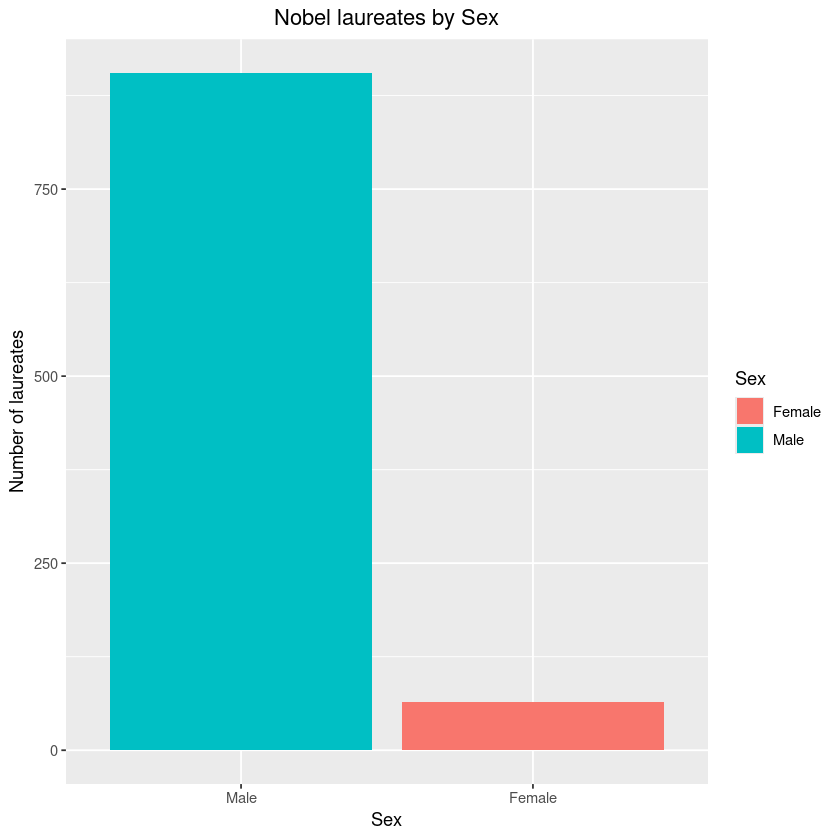

In [4]:
# Visualize the number of laureates by gender
top_g <-
nobel%>%
# Remove missing values
filter(!is.na(sex)) %>%
group_by(sex) %>%
summarise(count=n()) %>%
ungroup()

# Create a column chart
ggplot(
	top_g, 
	aes(
		# Order sex from highest to lowest count
		x=reorder(sex, -count), 
		y=count, 
		# Color bars by sex
		fill=sex
	   )
) +
	geom_col() +
	# Add title and axis labels
	labs(
		title = 'Nobel Laureates by Sex',
		x= 'Sex',
		y= 'Number of Laureates',
		fill = 'Sex'
	) +
	# Center the title
	theme(
		plot.title = element_text(hjust = 0.5)
	)

In [5]:
# 2. Which birth country has the most laureates?

# Similar to question 1 but the count method combines group_by() and summarise(n())
top_country <-
nobel %>%
count(birth_country, name = 'count') %>%
ungroup() %>%
arrange(desc(count)) %>%
slice(1) %>%
pull(birth_country) %>%
as.character()

top_country

[1] "United States of America"

In [6]:
# 3. Which decade had the highest proportion of US-born laureates?

# Add a decade column to nobel dataset
nobel <-
nobel %>%
mutate(decade = year - (year%%10))

max_decade_usa <-
nobel %>%
# Identify US-born laureates
mutate(us_born = birth_country == "United States of America") %>%
group_by(decade) %>%
# Calculate the proportion for US-born laureates of each decade, 
# ignoring missing values.
summarise(proportion=mean(us_born, na.rm=TRUE)) %>%
# Remove grouping 
ungroup() %>%
# Sort proportion from highest to lowest
arrange(desc(proportion)) %>%
# Take just the first row
slice(1) %>%
# Select the decade column
pull(decade) %>%
# Convert to integer
as.integer()

max_decade_usa

[1] 2000

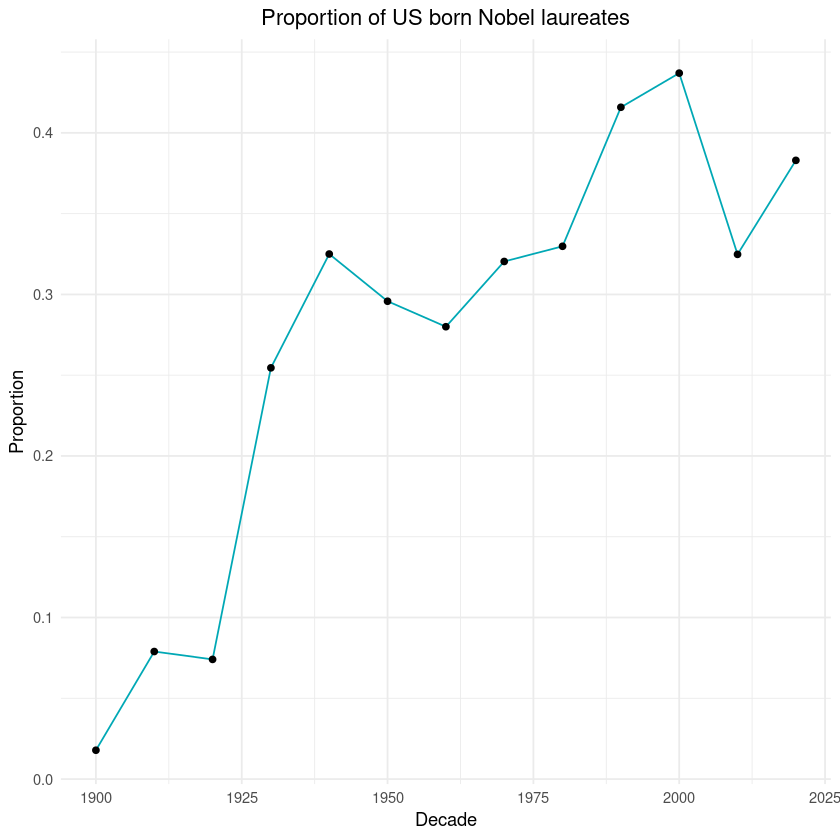

In [7]:
# Visualize the decades and their proportion of US-born laureates
us_prop <- 
nobel %>%
mutate(us_born = birth_country == "United States of America") %>%
group_by(decade) %>%
summarise(proportion=mean(us_born, na.rm=TRUE))

# Create a line chart
ggplot(
	us_prop, 
	aes(
		x=decade, 
		y=proportion
	)
) + 
	geom_line(color='#00A8B5') + 
	geom_point() +
	labs(
		title = 'Proportion of US born Nobel Laureates',
		x = 'Decade',
		y = 'Proportion'
	) +
	# Make the graph background lighter and cleaner
	 theme_minimal() +
	theme(
		plot.title = element_text(hjust=0.5)
	)

In [21]:
# 4. Which decade-category pair had the highest proportion of female laureates?
max_female_list <- 
suppressMessages(
nobel %>%
# Create two new columns in order to calculate the proportion
mutate(
	female_laureate = sex=='Female',
	all_laureates = sex==sex
) %>%
# Group by decade and category
group_by(decade, category) %>%
# Calculate the proportion by dividing female laureates by
# total laureates within each decade-category group
summarise(
proportion = sum(female_laureate, na.rm=TRUE)/
			 sum(all_laureates, na.rm=TRUE)) %>%
ungroup() %>%
arrange(desc(proportion)) %>%
slice(1) %>%
# Store the top decade-category pair in a list
summarise(
max_female_list = list(c(decade=decade, 
				  category=category))) %>%
pull(max_female_list)
)
max_female_list

[[1]]
  decade category 
  "2010"  "Peace"

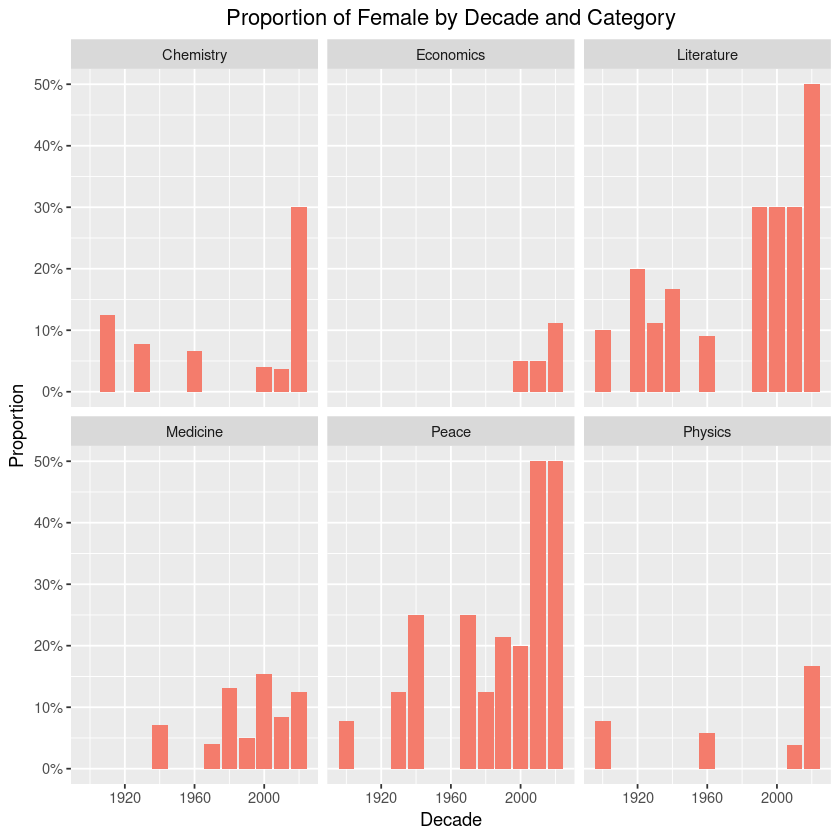

In [20]:
# Visualize the proportion of female laureates for each category by decade
female_cat <-
suppressMessages(
nobel %>%
mutate(
	female_laureate = sex=='Female',
	all_laureates = sex==sex
) %>%
group_by(decade, category) %>%
summarise(
proportion = sum(female_laureate, na.rm=TRUE)/
		     sum(all_laureates, na.rm=TRUE)) %>%
ungroup()
)

# Create a faceted column chart
ggplot(
	female_cat, 
	aes(
		x = decade, 
		y = proportion)
) +
	geom_col(fill='#F47C6C') +
	# Create a separate facet for each category
	facet_wrap(~category) +
	# Convert y-axis labels to percentages
	scale_y_continuous(
		labels = scales::percent) +
	labs(
		title = 'Proportion of Female Laureates by Decade and Category',
		x = 'Decade',
		y = 'Proportion'
	) +
	theme(
		plot.title = element_text(hjust=0.5)
	)

In [10]:
# 5. Who was the first woman to receive a Nobel Prize?
first_woman <- 
nobel %>%
# Keep only female laureates
filter(sex=="Female") %>%
arrange(year) %>%
slice(1) %>%
# Select the full_name and category columns
select(full_name, category)

# Select the full_name column from first_woman
# and assign to first_woman_name
first_woman_name <- first_woman$full_name
first_woman_name

[1] "Marie Curie, née Sklodowska"

In [11]:
# Select the category column from first_woman
# and assign to first_woman_category
first_woman_category <- first_woman$category
first_woman_category

[1] "Physics"

In [12]:
# 6. Which individuals or organizations have won multiple Nobel Prizes?
repeats <-
nobel %>%
group_by(full_name) %>%
summarise(count=n()) %>%
ungroup() %>%
filter(count>1) %>%
summarise(repeats = list(full_name)) %>%
pull()
repeats

[[1]]
[1] "Comité international de la Croix Rouge (International Committee of the Red Cross)"
[2] "Frederick Sanger"                                                                 
[3] "John Bardeen"                                                                     
[4] "Linus Carl Pauling"                                                               
[5] "Marie Curie, née Sklodowska"                                                      
[6] "Office of the United Nations High Commissioner for Refugees (UNHCR)"